In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import re
from AgentTorch.substep import SubstepTransition
from AgentTorch.helpers import get_by_path

In [3]:
# class MigrateTUCell(SubstepTransition):
#     """
#         Transition to migrate the tumor cells to a new location
#         Update the cell grid by altering positions of the cells (migration)

#         Args:
#             config (dict): the input state
#             input_variables (dict): dictionary of input variables
#             output_variables (dict): dictionary of output variables
#             arguments (dict): dictionary of arguments

#         Returns:
#             dict: the output state

#         Parameters:
#             migrate_cell_index (int): the index of the cell to migrate
        
#         Steps:
#             1. Feed the input state to the transition function
#             2. Get the index of the cell to migrate (from the action substep)
#             3. The index should be within the size of the cell grid
#             4. The prosition of the cell to migrate is set to 1 (true)
#             5. The original position of the cell is set to 0 (false)
#             6. Update the state by altering positions of the cells (migration)

#     """
    
#     def __init__(self, config, input_variables, output_variables, arguments):
#         super().__init__(config, input_variables, output_variables, arguments)

#     def forward(self, state):
#         input_variables = self.input_variables

#         migrate_cell_index = get_by_path(state, re.split("/", input_variables["migrate_cell_index"])).long()
#         cell_grid = state['cell_grid']
#         tumor_cell_id = self.config['agents']['tumorcells']['id']

#         def update_cell_property(agent_id, cell_grid):
#             ravel_cell_grid = cell_grid.ravel()
#             ravel_cell_grid[migrate_cell_index] = torch.ones_like(ravel_cell_grid[migrate_cell_index]) 
#             ravel_cell_grid[tumor_cell_id] = torch.zeros_like(ravel_cell_grid[tumor_cell_id])
#             new_cell_grid = ravel_cell_grid.reshape(cell_grid.shape)
#             return new_cell_grid
        
#         # Map the update function over the agents dimension
#         n_agents = state['cell_grid'].ravel().shape[0]
#         updated_cell_grids = torch.vmap(update_cell_property, in_dims=(0, None))(torch.arange(n_agents), cell_grid)
#         # Convert to tuple before stacking
#         print(updated_cell_grids.shape)
#         state['cell_grid'] = torch.stack(tuple(updated_cell_grids))

#         return state

In [4]:
# class MigrateTUCell(SubstepTransition):
#     def __init__(self, config, input_variables, output_variables, arguments):
#         super().__init__(config, input_variables, output_variables, arguments)

#     def forward(self, state):
#         input_variables = self.input_variables

#         migrate_cell_index = get_by_path(state, re.split("/", input_variables["migrate_cell_index"])).long()
#         tumor_cell_id = self.config['agents']['tumorcells']['id']

#         def migrate_cell(agent_matrix, old_loc, new_loc):
#             agent_matrix[new_loc] = 0
#             agent_matrix[old_loc] = 1
#             return agent_matrix
        
#         # n_agents = state['cell_grid'].ravel().shape[0]
#         cell_grid = state['cell_grid']
#         agent_matrix = cell_grid[tumor_cell_id, :]
#         updated_agent_matrix = torch.vmap(migrate_cell,  
#                                 in_dims=(0,None,None))(
#                                  agent_matrix, # matrix
#                                  migrate_cell_index, # new_locs
#                                  tumor_cell_id # old_locs
#                                  ) 

#         print(updated_agent_matrix.shape)
#         state['cell_grid'] = torch.stack(tuple(updated_agent_matrix))
#         return state

In [35]:
class MigrateTUCell(SubstepTransition):
    def __init__(self, config, input_variables, output_variables, arguments):
        super().__init__(config, input_variables, output_variables, arguments)

    def forward(self, state):
        input_variables = self.input_variables

        new_x = get_by_path(state, re.split("/", input_variables["new_x"]))[0]
        new_y = get_by_path(state, re.split("/", input_variables["new_y"]))[0]
        old_x = get_by_path(state, re.split("/", input_variables["old_x"]))[0]
        old_y = get_by_path(state, re.split("/", input_variables["old_y"]))[0]
        tumor_cell_id = self.config['agents']['tumorcells']['id']

        def migrate_cell(agent_matrix, old_x, old_y, new_x, new_y):
            # print(agent_matrix.shape)
            agent_matrix[new_x, new_y] = 0
            agent_matrix[old_x, old_y] = 1
            return agent_matrix

        cell_grid = state['cell_grid']

        # 3D agent_matrix of shape [num_agents , cell_grid_height , cell_grid_width]
        n_agents = state['cell_grid'].ravel().shape[0]
        agent_matrix = torch.zeros(n_agents, cell_grid.shape[0], cell_grid.shape[1])
        print(agent_matrix.shape)

        updated_cell_grids = torch.vmap(migrate_cell, 
                                        in_dims=(0,None,None,None,None))(
                                            agent_matrix, # matrix
                                            new_x, new_y, # new loc
                                            old_x, old_y  # old loc
                                            )
        
        # print(updated_cell_grids.shape)
        state['cell_grid'] = updated_cell_grids
        return state

In [36]:
config = {
    'agents': {
        'tumorcells': {
        'id': 1,
        'new_x': torch.randint(0, 10, (1,)),
        'new_y': torch.randint(0, 10, (1,)),
        'old_x': torch.randint(0, 10, (1,)),
        'old_y': torch.randint(0, 10, (1,)) 
        }
    },
    'cell_grid': torch.bernoulli(torch.rand(10, 10)),
    'steps': 1
}

input_variables = {
    'new_x': 'agents/tumorcells/new_x',
    'new_y': 'agents/tumorcells/new_y',
    'old_x': 'agents/tumorcells/old_x',
    'old_y': 'agents/tumorcells/old_y' 
}

output_variables = {}

arguments = {
    'learnable': {},
    'fixed': {},
}

migrate_tu_cell = MigrateTUCell(config, input_variables, output_variables, arguments)

In [37]:
output_state = migrate_tu_cell(config)

torch.Size([100, 10, 10])


In [31]:
print("\nState after Migration:")
print(output_state)


State after Migration:
{'agents': {'tumorcells': {'id': 1, 'new_x': tensor([0]), 'new_y': tensor([2]), 'old_x': tensor([2]), 'old_y': tensor([3])}}, 'cell_grid': tensor([[[0., 0., 1.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 1.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 1.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[0., 0., 1.,  ..., 0., 0., 0

In [51]:
output_state_sum = sum([torch.sum(tensor) for tensor in output_state['agents']['tumorcells'].values() if isinstance(tensor, torch.Tensor)])

In [8]:
print(output_state_sum)
loss = output_state_sum

tensor(4., grad_fn=<AddBackward0>)


In [9]:
loss.requires_grad

True

In [10]:
loss.backward()

In [11]:
input_state_sum = sum([torch.sum(tensor) for tensor in config['agents']['tumorcells'].values() if isinstance(tensor, torch.Tensor)])

In [12]:
input_state_sum.requires_grad

True

In [13]:
import torch
import torch.optim as optim

In [14]:
migrateTUcell = config['agents']['tumorcells']['migrate_cell_index']
optimizer = optim.SGD([migrateTUcell], lr=0.01)

In [ ]:
grad_values = []

for epoch in range(3):
    # Forward pass
    output_state = migrate_tu_cell(config)
    output_state_sum = sum([torch.sum(tensor) for tensor in output_state['agents']['tumorcells'].values() if isinstance(tensor, torch.Tensor)])
    loss = torch.sum(output_state_sum)
    # Backward pass
    loss.backward()
    # Print or plot the gradient values
    print('Gradient of migrateTUcell:', migrateTUcell.grad)
    # Store migrateTUcell.grad values in the list
    grad_values.append(migrateTUcell.grad.item())
    # Optimize
    optimizer.step()
    # Print or plot the updated migrateTUcell values
    print('Updated migrateTUcell:', migrateTUcell)
    # Print or plot the loss
    print('Loss:', loss.item())
    # Clear gradients for the next iteration
    optimizer.zero_grad()

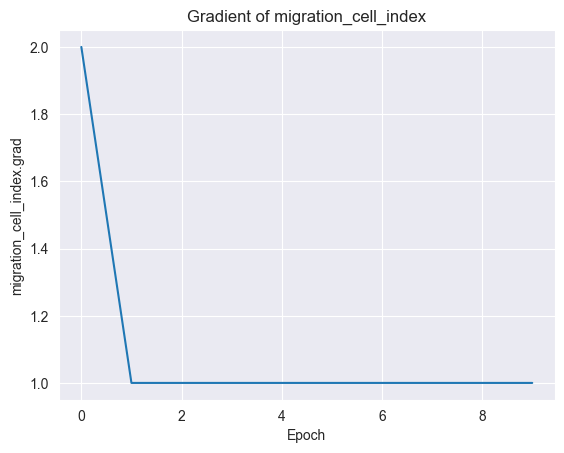

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.plot(grad_values)
plt.xlabel('Epoch')
plt.ylabel('migration_cell_index.grad')
plt.title('Gradient of migration_cell_index')
plt.show()